In [2]:
import pandas as pd
import numpy as np
import multiprocessing as mp
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap

import causalml
from causalml.metrics import plot_gain, plot_qini, qini_score
from causalml.dataset import synthetic_data
from causalml.inference.tree import plot_dist_tree_leaves_values, get_tree_leaves_mask
from causalml.inference.tree import CausalRandomForestRegressor, CausalTreeRegressor
from causalml.inference.tree.utils import timeit

import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [3]:
import importlib
for libname in ["causalml", "shap"]:
    print(f"{libname}: {importlib.metadata.version(libname)}")



causalml: 0.15.1
shap: 0.46.0


In [4]:
# Simulate randomized trial: mode=2
y, X, w, tau, b, e = synthetic_data(mode=2, n=2000, p=10, sigma=3.0)

df = pd.DataFrame(X)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df.columns = feature_names
df['outcome'] = y
df['treatment'] = w
df['treatment_effect'] = tau

In [71]:
# Split data to training and testing samples for model validation
df_train, df_test = train_test_split(df, test_size=0.2, random_state=111)
n_train, n_test = df_train.shape[0], df_test.shape[0]

X_train, y_train = df_train[feature_names], df_train['outcome'].values
X_test, y_test = df_test[feature_names], df_test['outcome'].values
treatment_train, treatment_test = df_train['treatment'].values, df_test['treatment'].values
effect_test = df_test['treatment_effect'].values

observation = X_test.loc[[0]]



In [72]:
print(treatment_train)
treatment_train = treatment_train[treatment_train !=1]
treatment_test = treatment_test[treatment_test !=1]

treatment_train

[1 0 1 ... 0 0 0]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [73]:
ctree = CausalTreeRegressor()
ctree.fit(X=X_train.values, y=y_train, treatment=treatment_train)

ValueError: The number of `treatment` and `y` rows are not equal: 1600 790

In [ ]:
crforest = CausalRandomForestRegressor(criterion="causal_mse",
                                  min_samples_leaf=200,
                                  control_name=0,
                                  n_estimators=50,
                                  n_jobs=mp.cpu_count() - 1)
crforest.fit(X=X_train, y=y_train, treatment=treatment_train)

CausalRandomForestRegressor(min_samples_leaf=200, n_estimators=50, n_jobs=7)

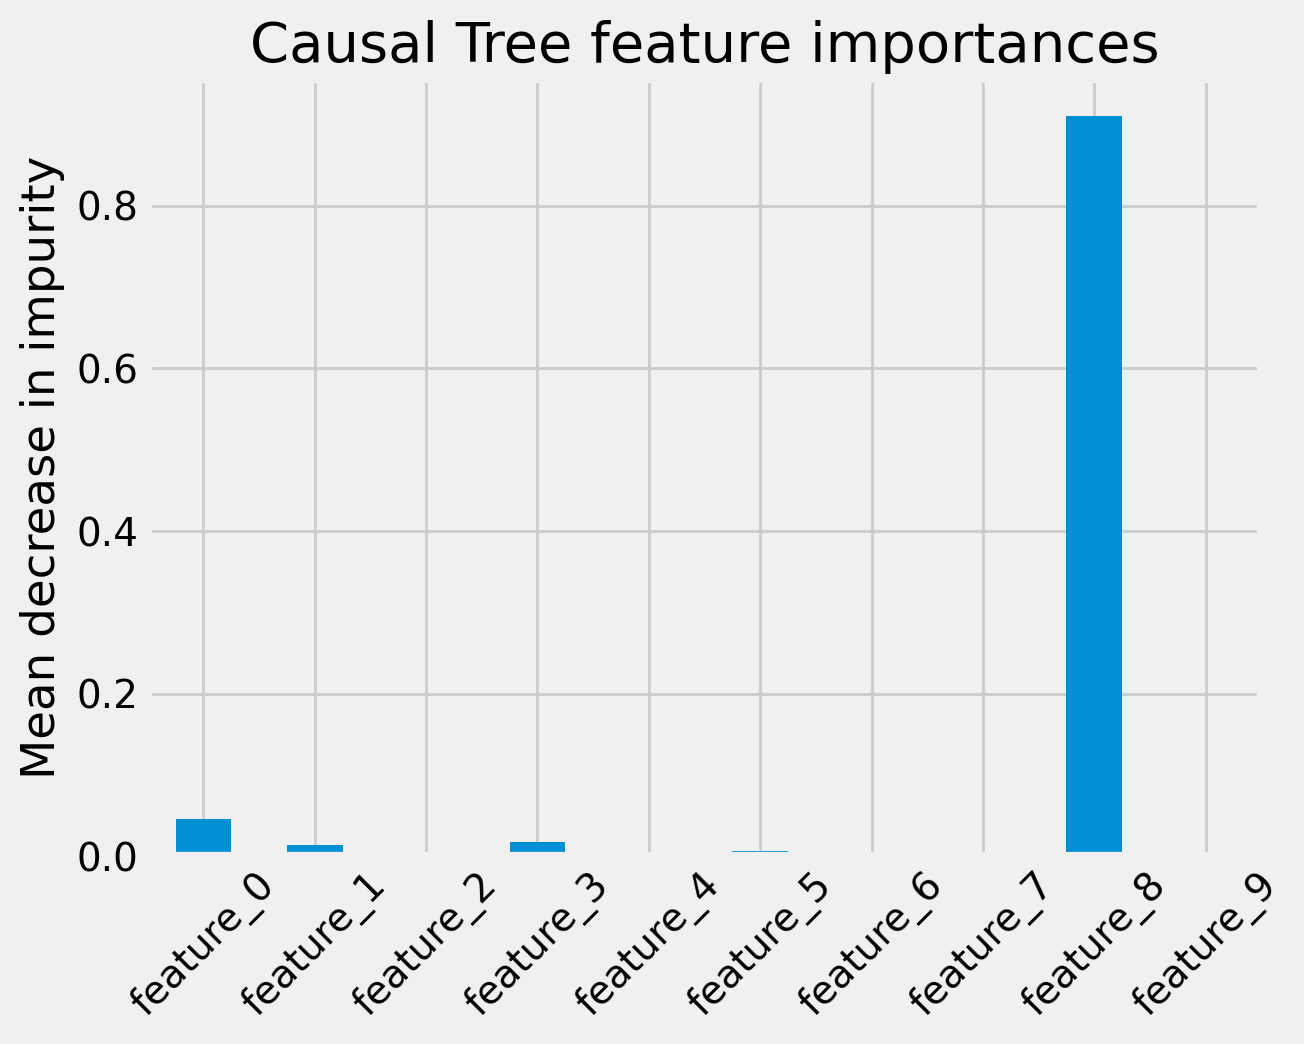

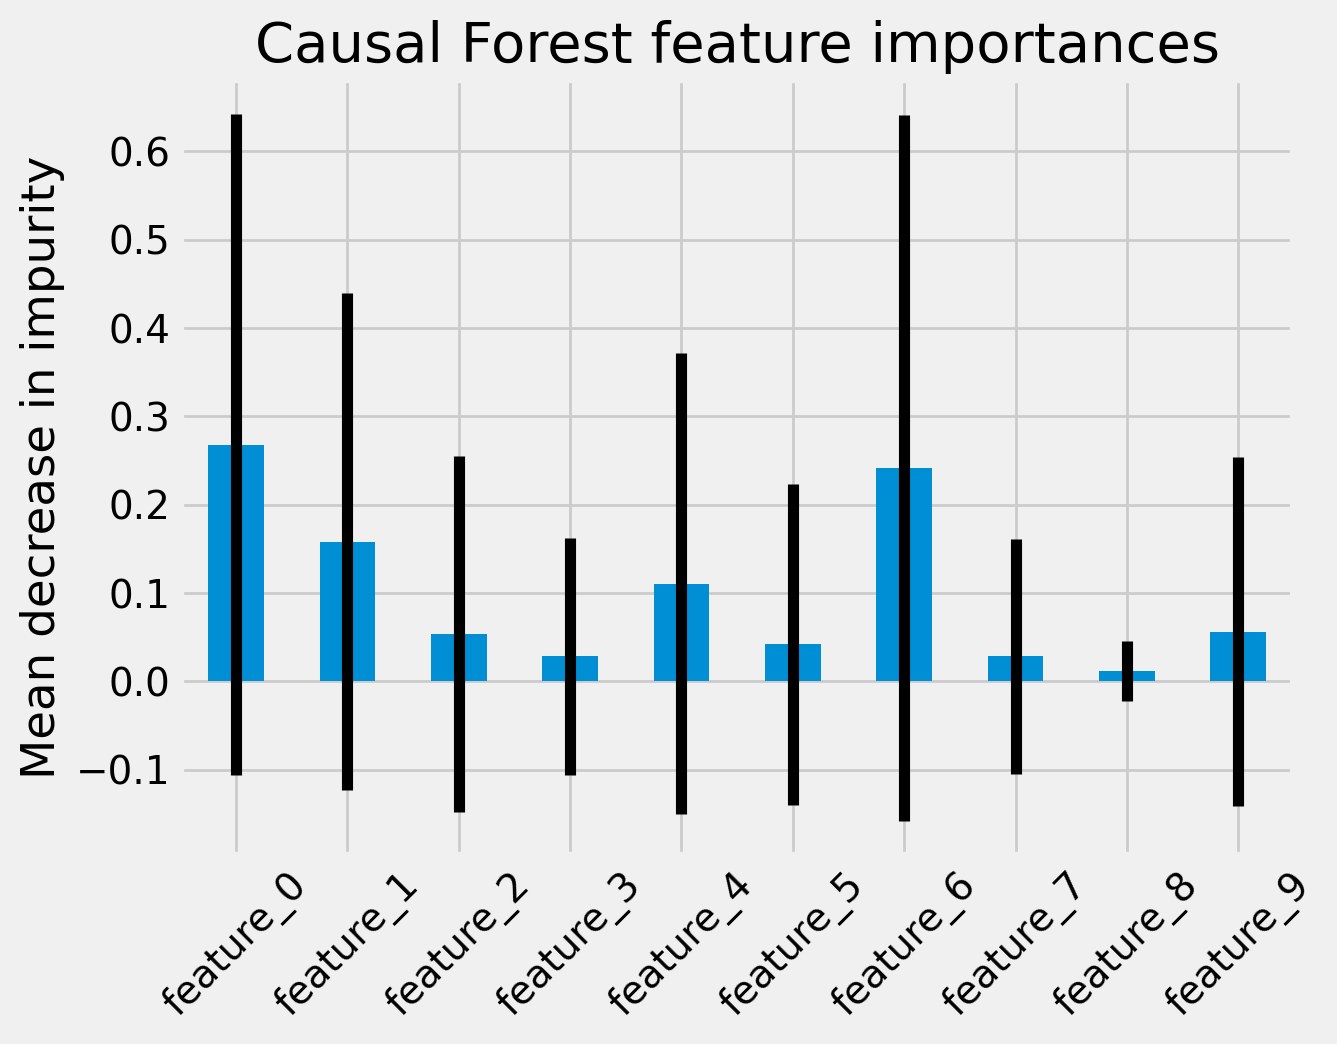

In [ ]:
df_importances = pd.DataFrame({'tree': ctree.feature_importances_,
                               'forest': crforest.feature_importances_,
                               'feature': feature_names
                              })
forest_std = np.std([tree.feature_importances_ for tree in crforest.estimators_], axis=0)

fig, ax = plt.subplots()
df_importances['tree'].plot.bar(ax=ax)
ax.set_title("Causal Tree feature importances")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xticklabels(feature_names, rotation=45)
plt.show()

fig, ax = plt.subplots()
df_importances['forest'].plot.bar(yerr=forest_std, ax=ax)
ax.set_title("Causal Forest feature importances")
ax.set_ylabel("Mean decrease in impurity")
ax.set_xticklabels(feature_names, rotation=45)
plt.show()



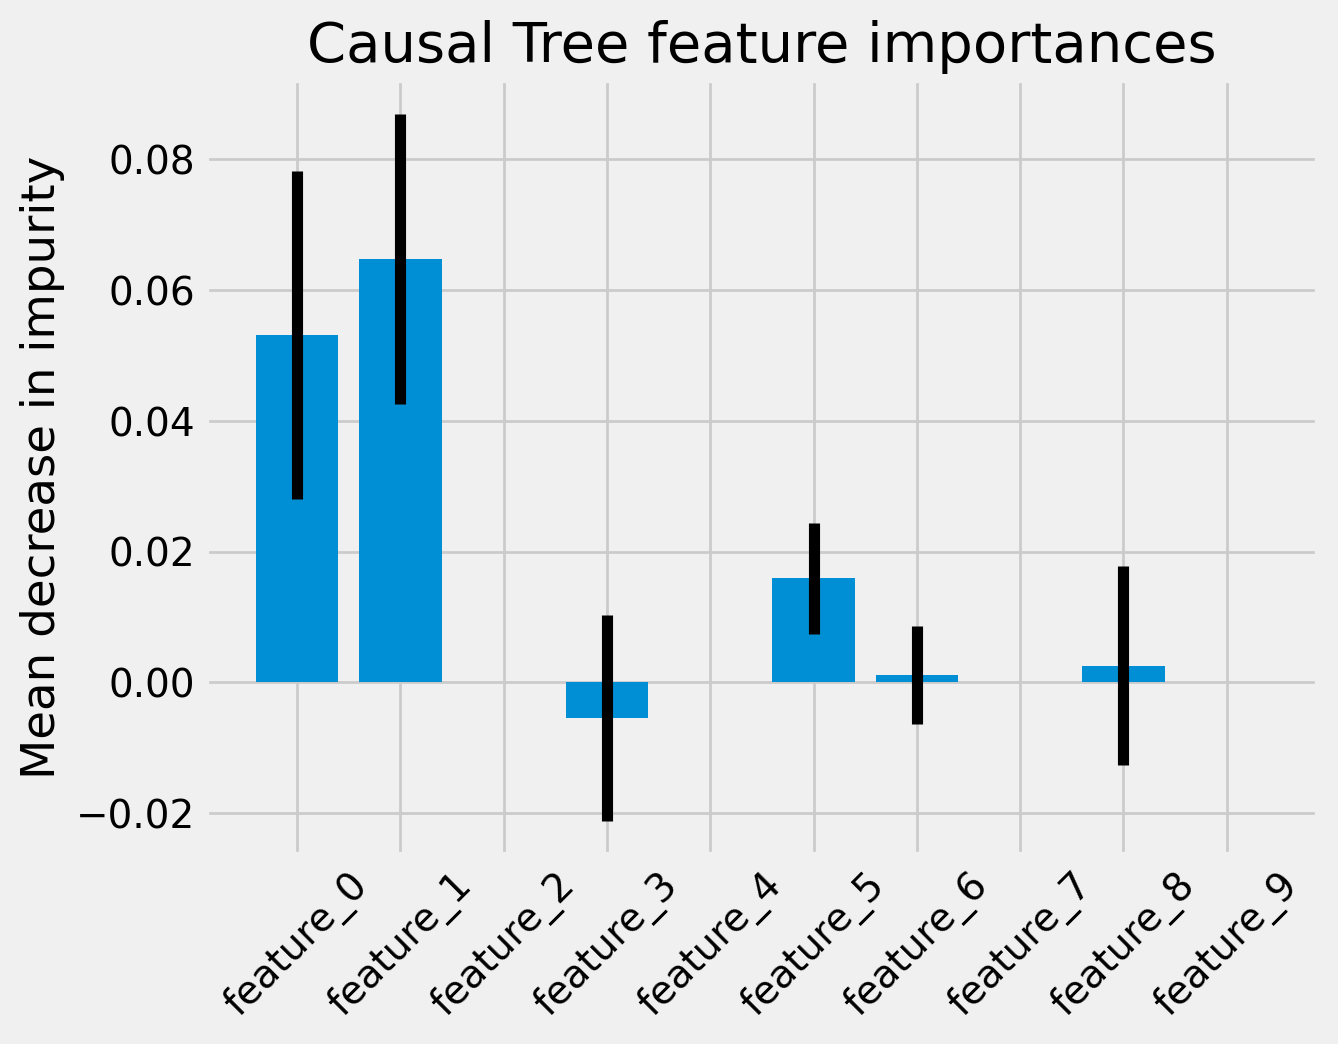

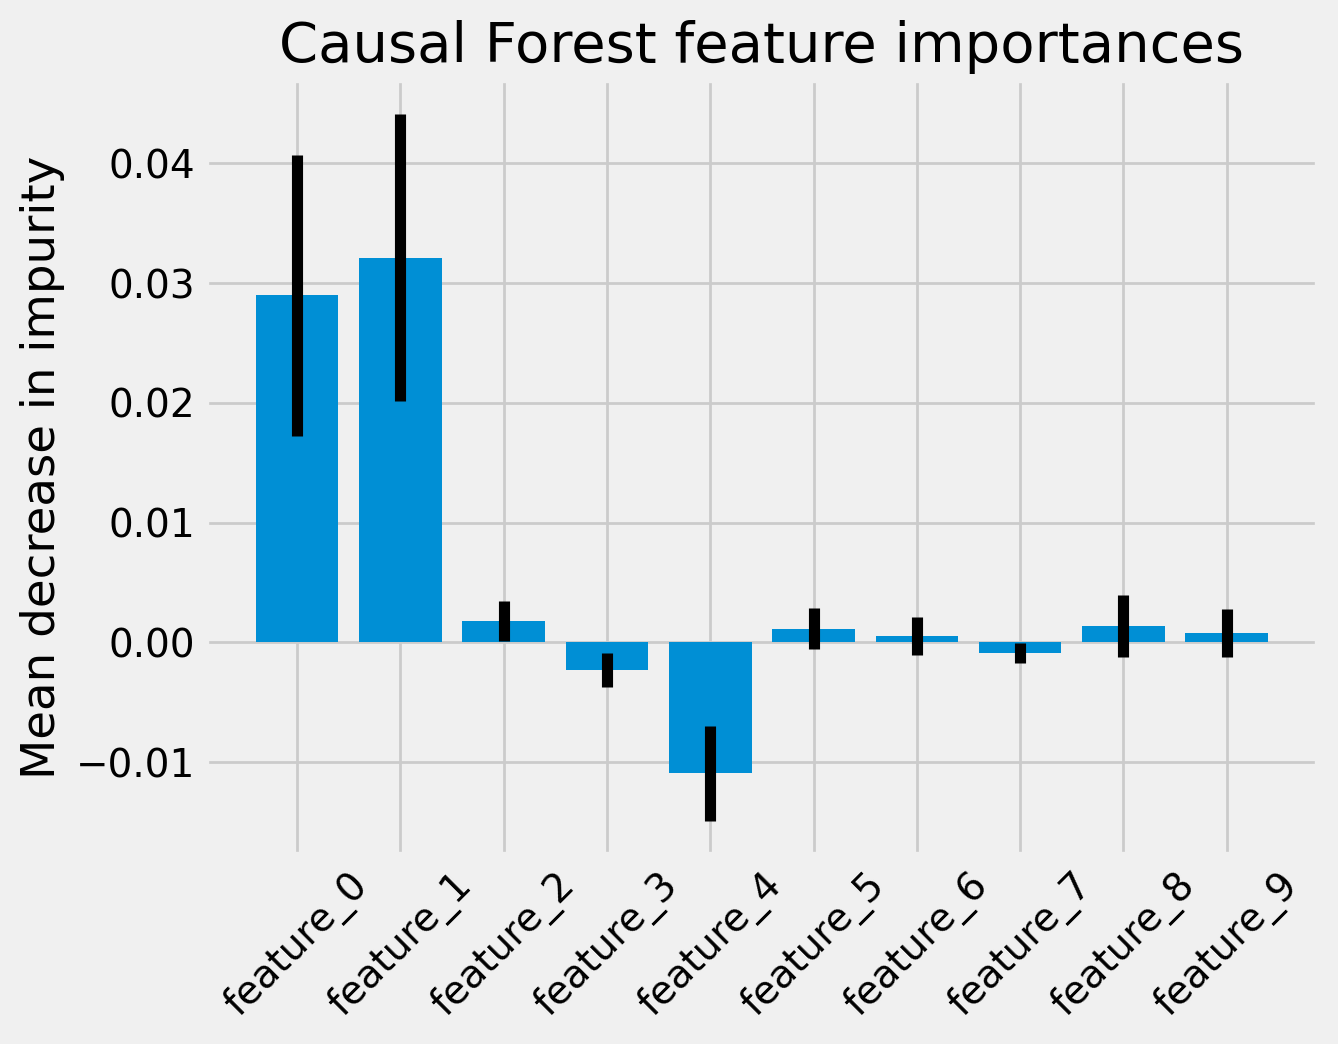

In [ ]:
for name, model in zip(('Causal Tree', 'Causal Forest'), (ctree, crforest)):

    imp = permutation_importance(model, X_test, y_test,
                                 n_repeats=50,
                                 random_state=0)

    fig, ax = plt.subplots()
    ax.set_title(f"{name} feature importances")
    ax.set_ylabel("Mean decrease in impurity")
    plt.bar(feature_names, imp['importances_mean'], yerr=imp['importances_std'])
    ax.set_xticklabels(feature_names, rotation=45)
    plt.show()

In [ ]:
X_train.values.shape
y_train.shape

(1600,)

In [ ]:
# tree_explainer = shap.TreeExplainer(crforest)
# # Expected values for treatment=0 and treatment=1. i.e. Y|X,T=0 and Y|X,T=1
# tree_explainer.expected_value
background = shap.sample(X_train.values, 100)

tree_explainer_t0 = shap.KernelExplainer(model=ctree.predict, data=background, treatment=0)
tree_explainer_t1 = shap.KernelExplainer(model=ctree.predict, data=background, treatment=1)


tree_explainer_t0.expected_value, tree_explainer_t1.expected_value



0.6386468795215192

In [ ]:
# Tree Explainer for treatment=0
shap.initjs()
shap_values = tree_explainer.shap_values(observation)
shap.force_plot(tree_explainer.expected_value,
                shap_values,
                observation)

100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


In [ ]:
forest_explainer = shap.KernelExplainer(model=ctree.predict, data=background)
shap_values = forest_explainer.shap_values(X_test.values)
forest_explainer.expected_value




100%|██████████| 400/400 [01:42<00:00,  3.91it/s]


0.638646879521519

In [ ]:
shap.initjs()
shap_values = forest_explainer.shap_values(observation)
shap.force_plot(forest_explainer.expected_value,
                shap_values,
                observation)

100%|██████████| 1/1 [00:00<00:00,  3.29it/s]
